In [1]:
from Kea.utils import plotting
import numpy as np
import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import scipy

c = plotting.COLOR_CYCLE_6

from sympy import *
from sympy.core import S

In [2]:

k = symbols('omega', positive=True, real=True)
l = symbols('tau', positive=True, real=True)

nu = symbols('H', positive=True, real=True)
#nu = Rational(1,2)

#a = symbols('A', positive=True, real=True)
#a = sqrt(pi) * gamma(nu + S(1)/S(2))/gamma(nu)
a = S(1)

E = (S(2)/pi) * (a**2 / (a**2 + k**2))**((S(1) + S(2)*nu) / S(2))

display(E.simplify())

R = integrate(E * cos(k * l), (k, 0, oo))
display(R.simplify())

SF = S(2) * limit(R, l, 0) - S(2) * R
#limit(R, l, 0) = 1

display(SF.simplify())

# Gives the same thing
#SF2 = 2 * integrate((1-cos(k*l))*E, (k, 0, oo))
#display(SF2.simplify())

b = symbols('b', positive=True, real=True)

eq_E = (1/b) * S(1)/S(2) * l**2 * diff(SF, l)

display(eq_E.simplify())


2*(omega**2 + 1)**(-H - 1/2)/pi

sqrt(pi)*(tau/2)**H*(besseli(-H, tau) - besseli(H, tau))/(sin(pi*H)*gamma(H + 1/2))

2**(1 - H)*(2**H - tau**H*besseli(-H, tau)*gamma(1 - H) + tau**H*besseli(H, tau)*gamma(1 - H))*gamma(H)/(sqrt(pi)*gamma(H + 1/2))

sqrt(pi)*(tau/2)**(H + 1)*(-2*H*besseli(-H, tau) + 2*H*besseli(H, tau) - tau*besseli(1 - H, tau) - tau*besseli(-H - 1, tau) + tau*besseli(H - 1, tau) + tau*besseli(H + 1, tau))/(b*sin(pi*H)*gamma(H + 1/2))

In [3]:

alpha = S(1) + S(2)*nu

bias = S(2)**(alpha/(alpha - S(1))) * (gamma(alpha/S(2) + S(1))/(sqrt(pi)*alpha))**(S(1)/(alpha - S(1)))*gamma(Rational(3,2) - alpha/S(2))**(-S(1)/(alpha - S(1)))
display(bias)

bias2 = S(2)*S(2)**(-alpha) * sqrt(pi) * (gamma((S(3) - alpha) / S(2))/gamma(alpha/S(2)))
display(bias2)


2**((2*H + 1)/(2*H))*(gamma(H + 3/2)/(sqrt(pi)*(2*H + 1)))**(1/(2*H))/gamma(1 - H)**(1/(2*H))

2*2**(-2*H - 1)*sqrt(pi)*gamma(1 - H)/gamma(H + 1/2)

In [4]:

sub_E = eq_E.subs({l: S(1)/k, b: S(1)})
display(sub_E.simplify())
d_eqE = k * diff(ln(sub_E), k)
display(d_eqE.simplify())

sub_E2 = eq_E.subs({l: b/k}).subs({b:bias})
display(sub_E2.simplify())
d_eqEb = k * diff(ln(sub_E2), k)
display(d_eqEb.simplify())

d_E = k * diff(ln(E), k)
display(d_E.simplify())


2**(-H - 1)*sqrt(pi)*omega**(-H - 2)*(-2*H*omega*besseli(-H, 1/omega) + 2*H*omega*besseli(H, 1/omega) - besseli(1 - H, 1/omega) - besseli(-H - 1, 1/omega) + besseli(H - 1, 1/omega) + besseli(H + 1, 1/omega))/(sin(pi*H)*gamma(H + 1/2))

-(4*H**2*omega**2*besseli(-H, 1/omega) - 4*H**2*omega**2*besseli(H, 1/omega) + 4*H*omega**2*besseli(-H, 1/omega) - 4*H*omega**2*besseli(H, 1/omega) + 4*H*omega*besseli(1 - H, 1/omega) + 4*H*omega*besseli(-H - 1, 1/omega) - 4*H*omega*besseli(H - 1, 1/omega) - 4*H*omega*besseli(H + 1, 1/omega) + 4*omega*besseli(1 - H, 1/omega) + 4*omega*besseli(-H - 1, 1/omega) - 4*omega*besseli(H - 1, 1/omega) - 4*omega*besseli(H + 1, 1/omega) + 2*besseli(-H, 1/omega) - 2*besseli(H, 1/omega) + besseli(2 - H, 1/omega) + besseli(-H - 2, 1/omega) - besseli(H - 2, 1/omega) - besseli(H + 2, 1/omega))/(2*omega*(2*H*omega*besseli(-H, 1/omega) - 2*H*omega*besseli(H, 1/omega) + besseli(1 - H, 1/omega) + besseli(-H - 1, 1/omega) - besseli(H - 1, 1/omega) - besseli(H + 1, 1/omega)))

sqrt(2)*pi**(1/4 - 1/(4*H))*omega**(-H - 2)*(2*H + 1)**(-1/2 - 1/(2*H))*(-2**(1/(2*H))*besseli(1 - H, 2**(1 + 1/(2*H))*gamma(H + 3/2)**(1/(2*H))/(pi**(1/(4*H))*omega*(2*H + 1)**(1/(2*H))*gamma(1 - H)**(1/(2*H))))*gamma(H + 3/2)**(1/(2*H)) - 2**(1/(2*H))*besseli(-H - 1, 2**(1 + 1/(2*H))*gamma(H + 3/2)**(1/(2*H))/(pi**(1/(4*H))*omega*(2*H + 1)**(1/(2*H))*gamma(1 - H)**(1/(2*H))))*gamma(H + 3/2)**(1/(2*H)) + 2**(1/(2*H))*besseli(H - 1, 2**(1 + 1/(2*H))*gamma(H + 3/2)**(1/(2*H))/(pi**(1/(4*H))*omega*(2*H + 1)**(1/(2*H))*gamma(1 - H)**(1/(2*H))))*gamma(H + 3/2)**(1/(2*H)) + 2**(1/(2*H))*besseli(H + 1, 2**(1 + 1/(2*H))*gamma(H + 3/2)**(1/(2*H))/(pi**(1/(4*H))*omega*(2*H + 1)**(1/(2*H))*gamma(1 - H)**(1/(2*H))))*gamma(H + 3/2)**(1/(2*H)) - pi**(1/(4*H))*H*omega*(2*H + 1)**(1/(2*H))*besseli(-H, 2**(1 + 1/(2*H))*gamma(H + 3/2)**(1/(2*H))/(pi**(1/(4*H))*omega*(2*H + 1)**(1/(2*H))*gamma(1 - H)**(1/(2*H))))*gamma(1 - H)**(1/(2*H)) + pi**(1/(4*H))*H*omega*(2*H + 1)**(1/(2*H))*besseli(H, 2**(1 + 1/(

4*2**(H - (3*H**2 + 2*H + 1)/H + 1/(2*H))*(1/(sqrt(pi)*(2*H + 1)))**(1/H)*(2*2**(2*H)*(2*sqrt(2)*pi**(1/4)*sqrt(2*H + 1)*gamma(H + 3/2))**(1/H)*besseli(-H, 2*2**(1/(2*H))*gamma(H + 3/2)**(1/(2*H))/(pi**(1/(4*H))*omega*(2*H + 1)**(1/(2*H))*gamma(1 - H)**(1/(2*H))))*gamma(1 - H)**(1/(2*H)) - 2*2**(2*H)*(2*sqrt(2)*pi**(1/4)*sqrt(2*H + 1)*gamma(H + 3/2))**(1/H)*besseli(H, 2*2**(1/(2*H))*gamma(H + 3/2)**(1/(2*H))/(pi**(1/(4*H))*omega*(2*H + 1)**(1/(2*H))*gamma(1 - H)**(1/(2*H))))*gamma(1 - H)**(1/(2*H)) + 2**(2*H + 1/(2*H))*H**2*omega**2*(pi**(3/4)*(2*H + 1)**(3/2))**(1/H)*besseli(-H, 2*2**(1/(2*H))*gamma(H + 3/2)**(1/(2*H))/(pi**(1/(4*H))*omega*(2*H + 1)**(1/(2*H))*gamma(1 - H)**(1/(2*H))))*gamma(1 - H)**(3/(2*H)) - 2**(2*H + 1/(2*H))*H**2*omega**2*(pi**(3/4)*(2*H + 1)**(3/2))**(1/H)*besseli(H, 2*2**(1/(2*H))*gamma(H + 3/2)**(1/(2*H))/(pi**(1/(4*H))*omega*(2*H + 1)**(1/(2*H))*gamma(1 - H)**(1/(2*H))))*gamma(1 - H)**(3/(2*H)) - 2**(2*H + 1/(2*H))*H*omega**2*(pi**(3/4)*(2*H + 1)**(3/2))**(1/

omega**2*(-2*H - 1)/(omega**2 + 1)

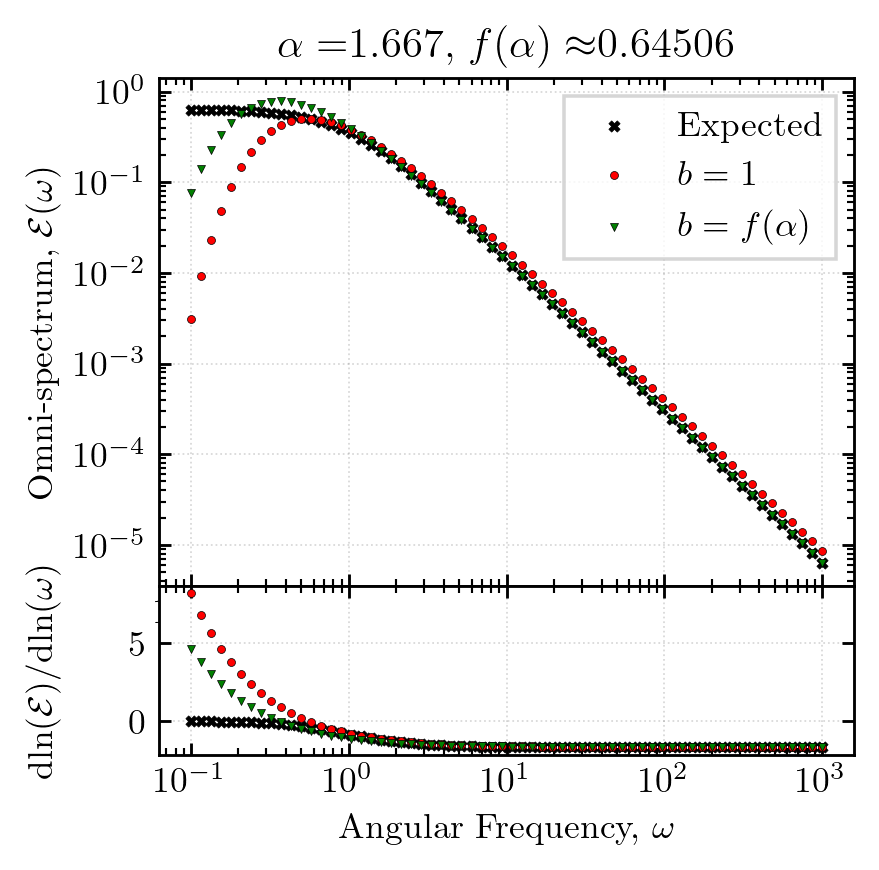

In [5]:
fig = plt.figure(1, dpi=256, figsize=(3.5, 3.5))
gs = mpl.gridspec.GridSpec(2, 1, height_ratios=[3, 1], figure=fig, hspace=0., wspace=0.)

ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
ax = [ax0, ax1]

_k = np.exp(np.linspace(np.log(0.1), np.log(1e3), 64))
_nu = 1./3.

for __k in _k:

    val = E.subs({k: __k, nu: _nu}).evalf()
    ax0.scatter(__k, val, marker='X', s=10., color='black', zorder=2, linewidth=0.2, edgecolor='black')

    val1 = eq_E.subs({l: 1./__k, nu: _nu, b: 1.}).evalf()
    ax0.scatter(__k, val1, marker='o', s=5., color='red', zorder=2, linewidth=0.2, edgecolor='black')

    b_true = bias.subs({nu: _nu}).evalf()

    val2 = eq_E.subs({l: b_true/__k, nu: _nu, b: b_true}).evalf()
    ax0.scatter(__k, val2, marker='v', s=5., color='green', zorder=2, linewidth=0.2, edgecolor='black')


    est_nu = d_eqE.subs({k: __k, nu: _nu}).evalf()
    est_true_nu = d_eqEb.subs({k: __k, nu: _nu}).evalf()
    true_nu = d_E.subs({k: __k, nu: _nu}).evalf()

    ax1.scatter(__k, true_nu, marker='X', s=10., color='black', zorder=2, linewidth=0.2, edgecolor='black')
    ax1.scatter(__k, est_nu, marker='o', s=5., color='red', zorder=2, linewidth=0.2, edgecolor='black')
    ax1.scatter(__k, est_true_nu, marker='v', s=5., color='green', zorder=2, linewidth=0.2, edgecolor='black')

#ax.loglog()

ax0.scatter([], [], marker='X', s=10., color='black', zorder=2, linewidth=0.2, edgecolor='black', label=r'Expected')
ax0.scatter([], [], marker='o', s=5., color='red', zorder=2, linewidth=0.2, edgecolor='black', label=r'$b=1$')
ax0.scatter([], [], marker='v', s=5., color='green', zorder=2, linewidth=0.2, edgecolor='black', label=r'$b=f(\alpha)$')

ax0.legend(frameon=True, fancybox=False)

#ax1.plot(_k, np.ones_like(_k)*bias2.subs({nu: _nu}).evalf(), color='black', linestyle='--', linewidth=2., zorder=1)

for axx in ax:
    axx.yaxis.set_ticks_position('both')
    axx.xaxis.set_ticks_position('both')
    axx.tick_params(axis='y', direction='in')
    axx.tick_params(axis='y', direction='in', which='minor')
    axx.tick_params(axis='x', direction='in')
    axx.tick_params(axis='x', direction='in', which='minor')
    axx.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
    axx.loglog()

ax1.set_yscale('linear')

#ax1.set_ylim((5e-1, 2e0))

ax0.set_ylabel(r'Omni-spectrum, $\mathcal{E}(\omega)$')
ax1.set_ylabel(r'd$\ln (\mathcal{E}) /$d$\ln (\omega)$')
ax1.set_xlabel(r'Angular Frequency, $\omega$')

alpha_title = np.float64(1. + 2.*_nu).round(decimals=3)
f_title = np.float64(bias.subs({nu: _nu}).evalf()).round(decimals=5)

ax0.set_title(r'$\alpha=$%s, $f(\alpha)\approx$%s' % (alpha_title, f_title))

fig.align_ylabels()

# fig.savefig('plots/semi_analytical_equiv_sf_ex.pdf', transparent=True, bbox_inches='tight', pad_inches=0)
# fig.savefig('plots/semi_analytical_equiv_sf_ex.png', transparent=True, bbox_inches='tight', pad_inches=0)


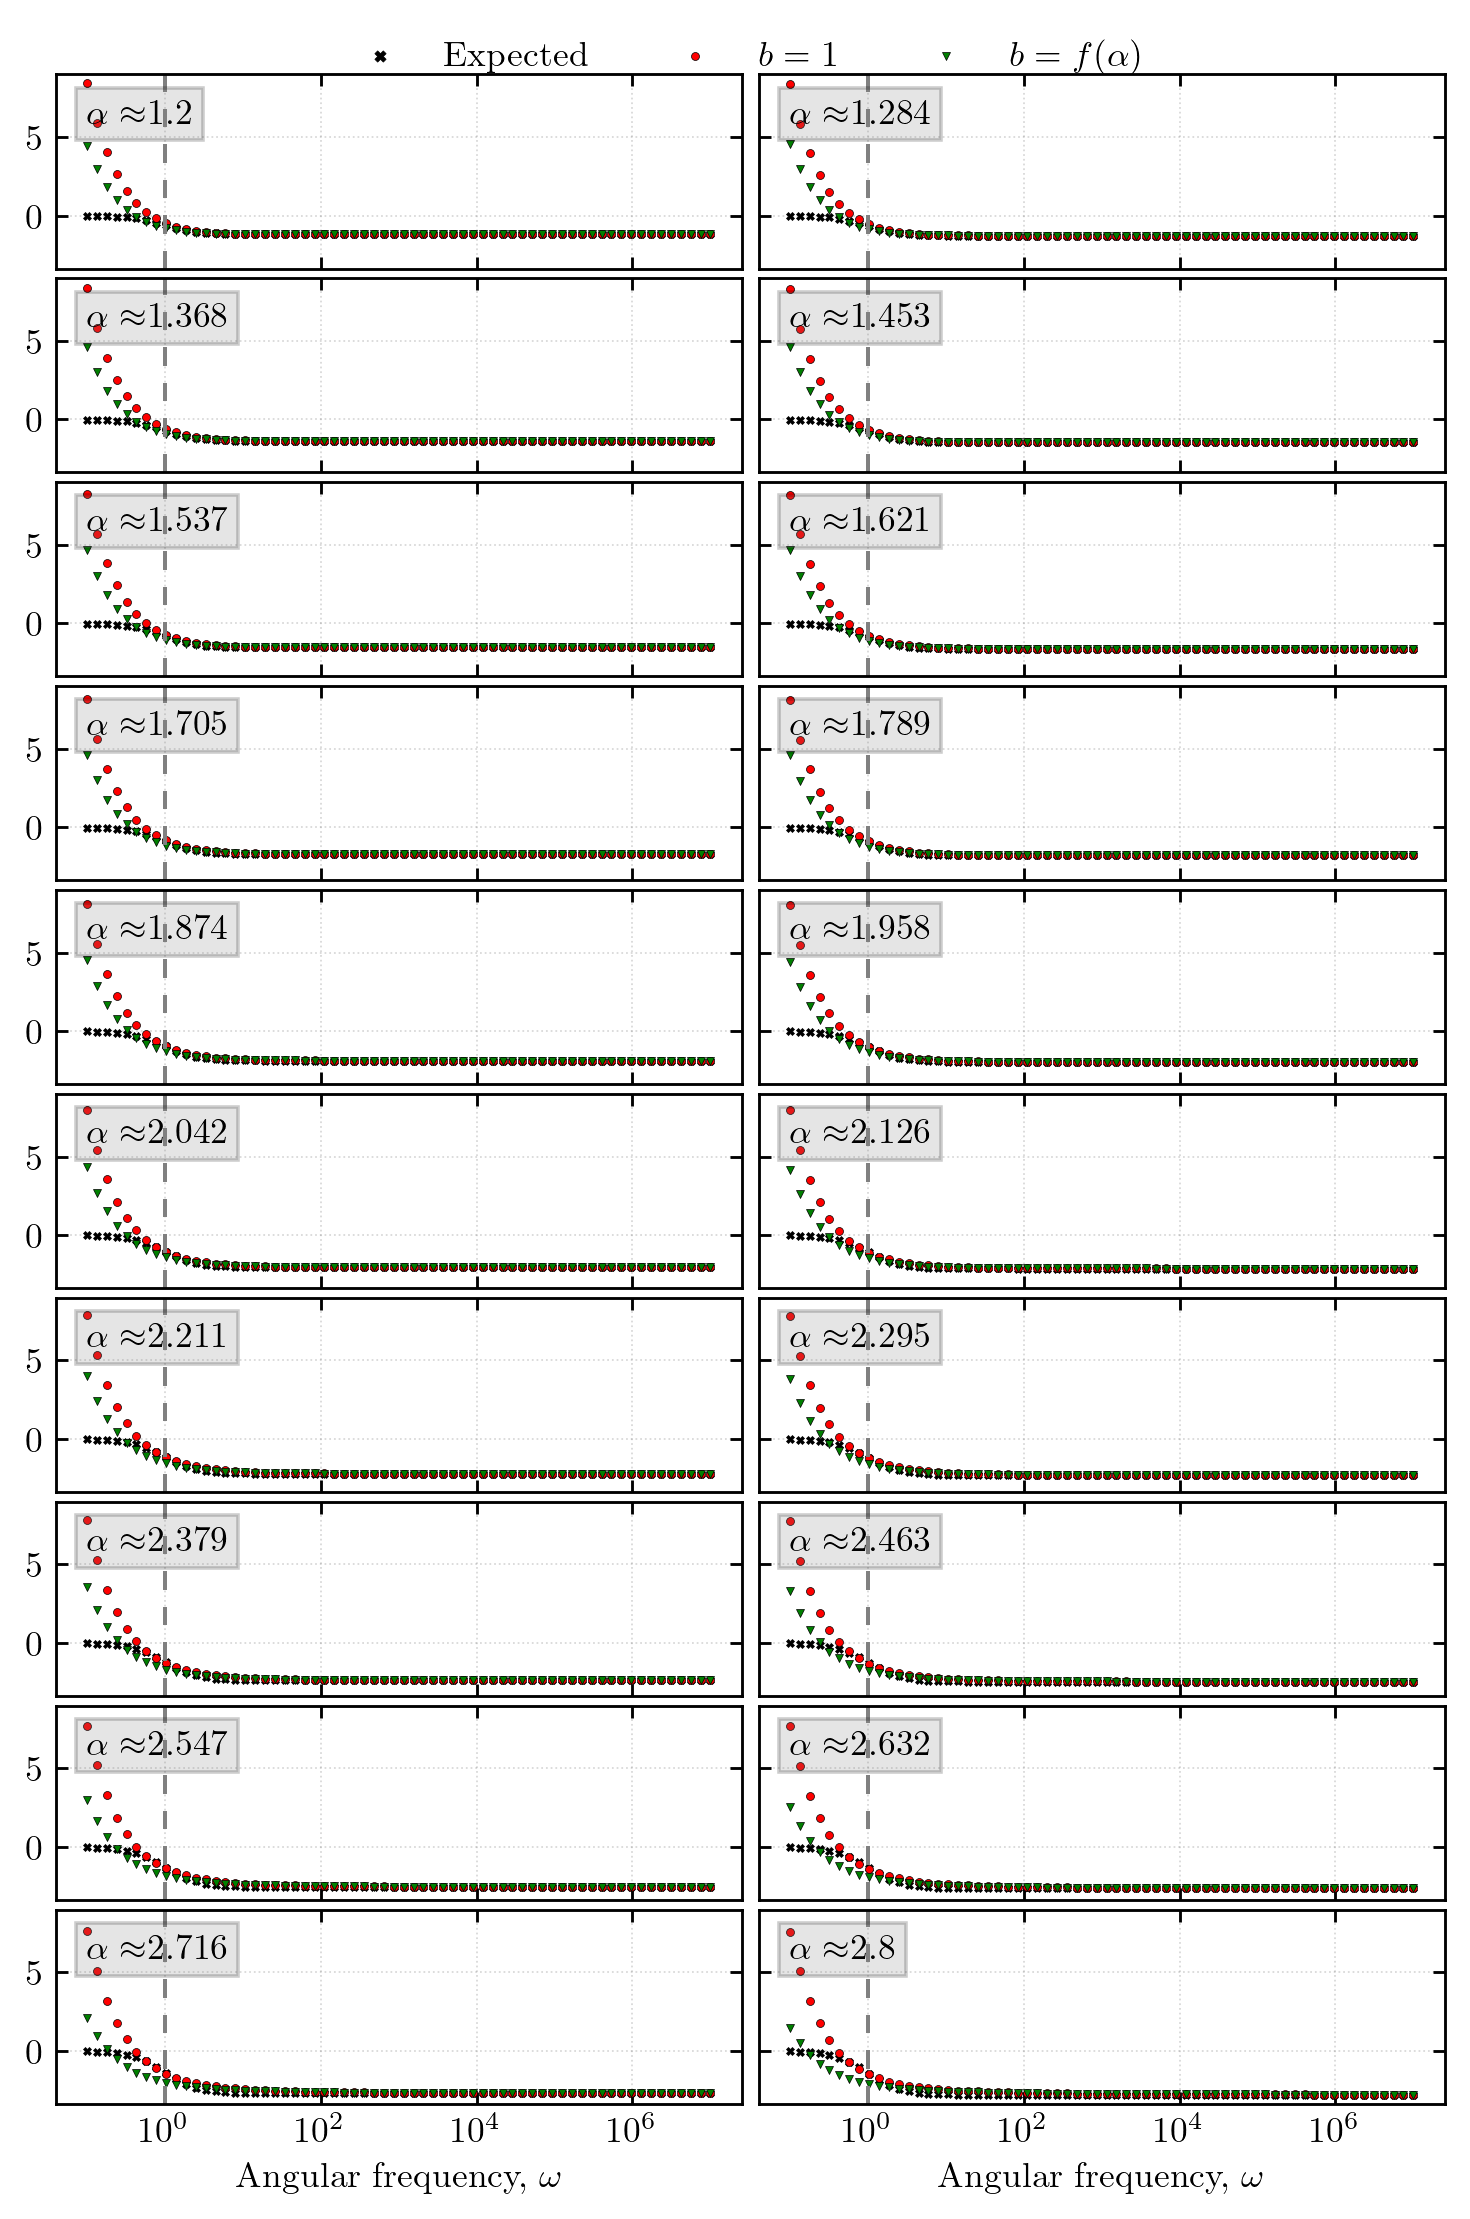

In [6]:

fig, ax = plt.subplots(10, 2, figsize=(7., 10.5), dpi=256, sharex=True, sharey=True)

_k = np.exp(np.linspace(np.log(0.1), np.log(1e7), 64))
nus = np.linspace(0.1, 0.9, 20)

props = dict(boxstyle='Square', edgecolor='black', linewidth=1., facecolor='gray', alpha=0.2)

_a = 0
for _i in range(10):
    for _j in range(2):
        _nu = nus[_a]

        for __k in _k:
            est_nu = d_eqE.subs({k: __k, nu: _nu}).evalf()
            est_true_nu = d_eqEb.subs({k: __k, nu: _nu}).evalf()
            true_nu = d_E.subs({k: __k, nu: _nu}).evalf()

            ax[_i][_j].scatter(__k, true_nu, marker='X', s=5., color='black', zorder=2, linewidth=0.2, edgecolor='black')
            ax[_i][_j].scatter(__k, est_nu, marker='o', s=5., color='red', zorder=2, linewidth=0.2, edgecolor='black')
            ax[_i][_j].scatter(__k, est_true_nu, marker='v', s=5., color='green', zorder=2, linewidth=0.2, edgecolor='black')

            #ax[_i][_j].axvline(a.subs({nu: _nu}).evalf(), color='gray', linestyle=(0,(5,5)), linewidth=1.)
            ax[_i][_j].axvline(a.evalf(), color='gray', linestyle=(0,(5,5)), linewidth=1.)

        ax[_i][_j].text(0.1, 0.75, r'$\alpha\approx$%s' % (np.float64(1. + 2.*_nu).round(decimals=3)), color='black', transform=ax[_i][_j].get_xaxis_transform(), bbox=props)

        _a = _a + 1

for aax in ax:
    for aaax in aax:
        aaax.yaxis.set_ticks_position('both')
        aaax.xaxis.set_ticks_position('both')
        aaax.tick_params(axis='y', direction='in')
        aaax.tick_params(axis='x', direction='in')
        aaax.tick_params(axis='y', direction='in', which='minor')
        aaax.tick_params(axis='x', direction='in', which='minor')

        aaax.set_xscale('log')
        #aaax.set_yscale('log')
        aaax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

        #aaax.set_ylim((2e-1, 9e0))
        #aaax.set_yticks([1e-1, 1e0, 1e1])

ax[-1][0].set_xlabel('Angular frequency, $\omega$')
ax[-1][1].set_xlabel('Angular frequency, $\omega$')

ax[0][0].scatter([], [], marker='X', s=10., color='black', zorder=2, linewidth=0.2, edgecolor='black', label=r'Expected')
ax[0][0].scatter([], [], marker='o', s=5., color='red', zorder=2, linewidth=0.2, edgecolor='black', label=r'$b=1$')
ax[0][0].scatter([], [], marker='v', s=5., color='green', zorder=2, linewidth=0.2, edgecolor='black', label=r'$b=f(\alpha)$')
#ax[0][0].scatter([], [], marker='v', s=5., color='blue', zorder=2, linewidth=0.2, edgecolor='black', label=r'$b=\tilde{f}(\alpha)$')
#ax.plot([], [], color='black', linewidth=0.5, linestyle=(0,(5,5)), label=r'Analytical Ar\'evalo')
fig.legend(fancybox=False, frameon=False, ncol=4, bbox_to_anchor=(0.75, 0.905))

fig.subplots_adjust(hspace=0.05, wspace=0.025)

